In [1]:
import polars as pl
import os
from PIL import Image

BASEPATH = "/home/affahrizain/projects/datasets/geotir"

In [3]:
df = pl.read_csv(os.path.join(BASEPATH, "jp_gldv_mp16_merged_saliency.csv"))
df.head()

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
20,"""4e7bf3e2529ae499""",31.564831,130.560186,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kagoshima-shi""",0.094482,0.15,false,"""sports venue""","""gldv2-full""","""train""","""The image displays a large, op…","""sports venue""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
6,"""8d6d459d74c62469""",33.592194,130.40675,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fukuoka-shi""",0.480467,0.15,true,"""church""","""gldv2-full""","""train""","""The image displays a large, re…","""dam""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
17,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""shinto shrine""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
18,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""dam""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
37,"""cf724c3632280892""",34.673972,133.299944,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fuchucho""",0.181179,0.15,true,null,"""gldv2-full""","""train""","""The image shows a large, multi…","""city""","""The main architectural structu…",0.35,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null


In [6]:
df["scene_type"].unique(), df["viewpoint"].unique()

(shape: (3,)
 Series: 'scene_type' [str]
 [
 	"indoor"
 	"ambiguous"
 	"outdoor"
 ],
 shape: (5,)
 Series: 'viewpoint' [str]
 [
 	"other"
 	"aerial_overhead"
 	"interior"
 	"exterior_facing_landmark"
 	"from_landmark_top"
 ])

In [66]:
exteriors = (
    df.filter(pl.col("is_semantically_salient") & pl.col("is_structurally_salient"))
    .filter(pl.col("scene_type") != "ambiguous")
    .filter(pl.col("viewpoint").is_in(["interior", "exterior_facing_landmark"]))
    .filter(pl.col("landmark_category") != "non_landmark")
    .to_dicts()
)
len(exteriors)

159390

In [86]:
"sasata.jpg".endswith(".jpg")

True

In [89]:
df.filter(pl.col("is_semantically_salient") & pl.col("is_structurally_salient")).filter(
    pl.col("scene_type") != "ambiguous"
).filter(pl.col("viewpoint").is_in(["interior", "exterior_facing_landmark"])).filter(
    pl.col("landmark_category") != "non_landmark"
).unique("id").with_columns(
    pl.col("id").map_elements(lambda x: x.strip(".jpg") if x.endswith(".jpg") else x)
).drop("row_idx").write_csv(os.path.join(BASEPATH, "jp_saliency_clean.csv"))

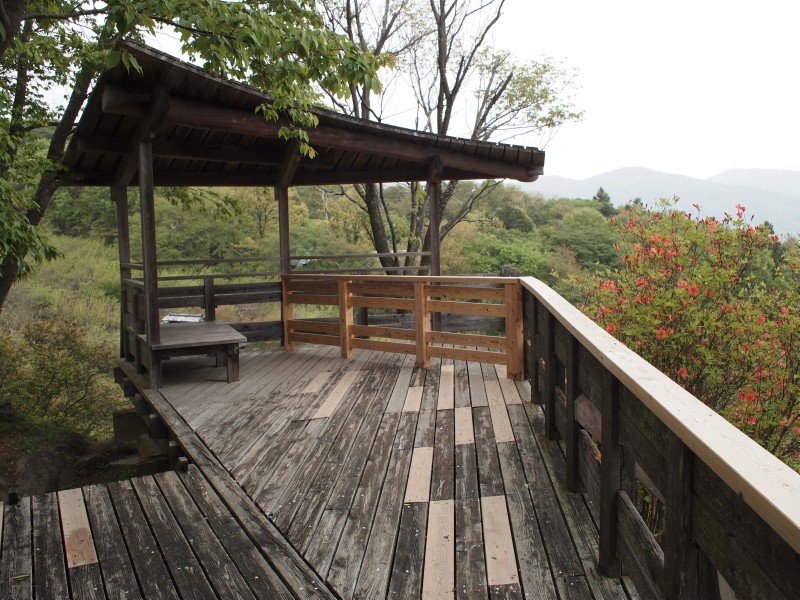

In [80]:
item = exteriors[13]
Image.open(
    os.path.join(
        BASEPATH,
        item["dataset"],
        item["src"],
        (f"{item['id']}.jpg" if item["dataset"] == "gldv2-full" else f"{item['id']}"),
    )
)

In [3]:
import polars as pl
from sklearn.model_selection import train_test_split

df = pl.read_csv(os.path.join(BASEPATH, "jp_saliency_clean.csv"))
df.head()

id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
"""52_cf_5053169213""",35.669107,139.77981,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,null,"""mp16""","""images""","""The image displays a tradition…","""shinto_shrine""","""The structure occupies approxi…",0.45,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A traditional wooden Shinto sh…",null
"""6c5a9ebea2877303""",34.6539,135.117,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kobe""",0.044677,0.15,false,"""garden""","""gldv2-full""","""train""","""The image displays a grand, sy…","""palace""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
"""afdfbc150bbeb4cd""",35.157222,136.899444,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Nagoya-shi""",0.143158,0.15,false,"""temple""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto_shrine""","""The structure occupies approxi…",0.65,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
"""d0_db_9632354627""",35.487258,139.62593,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Yokohama""",0.0,0.15,false,null,"""mp16""","""images""","""The image displays a large, na…","""garden""","""The main architectural structu…",0.05,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A large stone sign reading 'GA…",null
"""57_55_3054446670""",35.431313,139.40202,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Atsugi""",0.69042,0.15,true,null,"""mp16""","""images""","""The image displays a small, re…","""shinto_shrine""","""The structure occupies approxi…",0.45,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A small, rectangular wooden Sh…",null


In [21]:
train, test = train_test_split(df, test_size=0.05, stratify=df["viewpoint"])
train, val = train_test_split(train, test_size=0.1, stratify=train["viewpoint"])

len(train), len(val), len(test)

(122837, 13649, 7184)